In [ ]:
!pip install lime scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b4e3f9fa6b89ffcf31e65852d0340cd8981011727c1cc26b63aab4129f53f57d
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


100%|██████████| 170M/170M [00:11<00:00, 14.3MB/s]


Training Started...

Epoch 1, Loss: 1268.425
Epoch 2, Loss: 1035.253
Epoch 3, Loss: 932.893

Training Completed


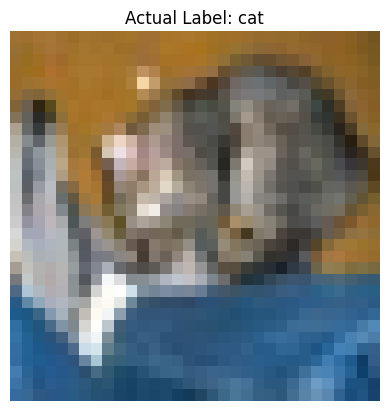

Generating LIME Explanation...


  0%|          | 0/1000 [00:00<?, ?it/s]

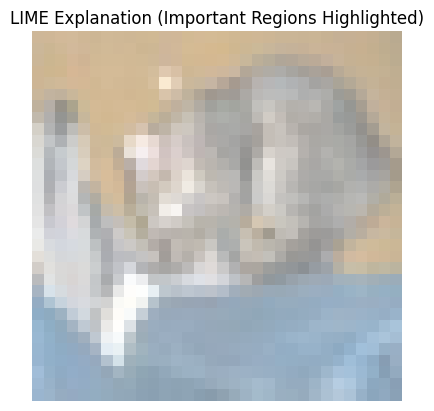

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from lime import lime_image
from skimage.segmentation import mark_boundaries

transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = trainset.classes

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.fc1 = nn.Linear(32 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Training Started...\n")

for epoch in range(3):
    running_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.3f}")

print("\nTraining Completed")

def predict(images):
    images = torch.tensor(images).permute(0, 3, 1, 2).float()
    outputs = model(images)
    probs = torch.softmax(outputs, dim=1)
    return probs.detach().numpy()

dataiter = iter(testloader)
images, labels = next(dataiter)

image = images[0].permute(1, 2, 0).numpy()
label = labels[0].item()

plt.imshow(image)
plt.title(f"Actual Label: {classes[label]}")
plt.axis('off')
plt.show()

explainer = lime_image.LimeImageExplainer()

print("Generating LIME Explanation...")

explanation = explainer.explain_instance(
    image,
    predict,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.title("LIME Explanation (Important Regions Highlighted)")
plt.axis('off')
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from lime import lime_image
from skimage.segmentation import mark_boundaries

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = trainset.classes

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.fc1 = nn.Linear(32 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN()

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
print("Training Started...\n")

for epoch in range(3):
    running_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.3f}")

print("\nTraining Completed")

Training Started...

Epoch 1, Loss: 1299.717
Epoch 2, Loss: 1068.559
Epoch 3, Loss: 967.164

Training Completed


In [8]:
def predict(images):
    images = torch.tensor(images).permute(0, 3, 1, 2).float()
    outputs = model(images)
    probs = torch.softmax(outputs, dim=1)
    return probs.detach().numpy()

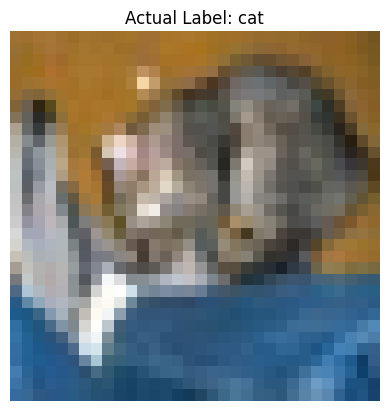

In [9]:
dataiter = iter(testloader)
images, labels = next(dataiter)

image = images[0].permute(1, 2, 0).numpy()
label = labels[0].item()

plt.imshow(image)
plt.title(f"Actual Label: {classes[label]}")
plt.axis('off')
plt.show()

Generating LIME Explanation...


  0%|          | 0/1000 [00:00<?, ?it/s]

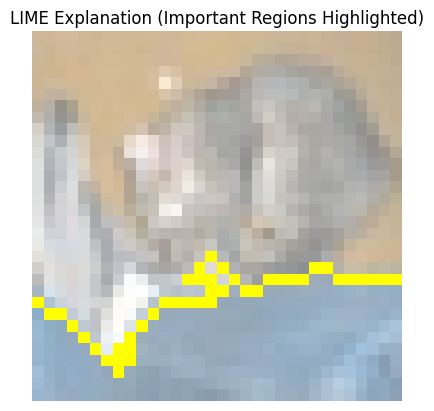

In [10]:
explainer = lime_image.LimeImageExplainer()

print("Generating LIME Explanation...")

explanation = explainer.explain_instance(
    image,
    predict,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.title("LIME Explanation (Important Regions Highlighted)")
plt.axis('off')
plt.show()